# DAY 2 — ESS 배터리 수명 예측 모델링

초기 100사이클의 신호로 최종 수명(`cycle_life`)을 예측한다. Day 1 EDA에서 세 배치에 공통으로 확인된 `ΔQ(V) 분산`을 핵심 피처로 사용하고, C-rate와 초기 평균 온도가 검증 성능을 실제로 개선하는지 비교한다.

## 분석 원칙

- **학습·모델 선택:** Batch 1
- **최종 일반화 평가:** Batch 2를 한 번만 사용
- **선택적 추가 확인:** Batch 3
- **데이터 기준:** 과제 제공 파일을 그대로 사용하고 `cycle_life` 결측 셀만 제외
- **주요 평가 지표:** MAPE
- **미래정보 차단:** 전체 열화 곡선이 필요한 Knee Point는 입력 피처에서 제외

## 1. 실행 환경과 데이터 경로

Day 1과 동일한 원본 파일과 피처 정의를 사용한다. 과제에서 제공한 Batch 1·2·3 파일의 `cycle_life`를 목표값으로 사용하며, 목표값이 없는 셀만 지도학습에서 제외한다. 이 기준의 유효 표본은 Batch 1 46개, Batch 2 39개, Batch 3 44개다.

원논문의 41·43·40개 전처리 구성을 재현하지 않으므로 원논문 MAPE 9.1%는 참고 성능으로 비교한다. Batch 2의 내부저항 0값은 측정 누락 가능성이 커 초기 모델 피처에서 사용하지 않는다.


In [1]:
from pathlib import Path
import warnings

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.base import clone
from sklearn.compose import TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import ElasticNet, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=UserWarning)
RANDOM_STATE = 42
PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "archive"
FIGURE_DIR = PROJECT_DIR / "figures" / "day2"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
BATCH_FILES = {
    "Batch 1": DATA_DIR / "2017-05-12_batchdata_updated_struct_errorcorrect.mat",
    "Batch 2": DATA_DIR / "2018-02-20_batchdata_updated_struct_errorcorrect.mat",
    "Batch 3": DATA_DIR / "2018-04-12_batchdata_updated_struct_errorcorrect.mat",
}
for name, path in BATCH_FILES.items():
    assert path.is_file(), f"{name} 파일을 찾을 수 없습니다: {path}"

pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid", context="notebook")

## 2. 초기 100사이클 피처 생성

피처는 최종 수명을 알기 전에 계산할 수 있는 값으로 제한한다.

- `log10_deltaq_variance`: 100번째와 10번째 사이클의 Q(V) 차이 분산
- `effective_c_rate_to_80pct`: 80% SOC까지의 유효 충전 속도
- `mean_Tavg_first100`: 초기 100사이클 평균 온도

In [2]:
def read_text(dataset, file):
    return "".join(chr(int(x)) for x in np.asarray(file[dataset]).ravel())


def extract_batch_features(batch_name, file_path):
    rows = []
    with h5py.File(file_path, "r") as f:
        batch = f["batch"]
        for cell_id in range(batch["cycle_life"].shape[0]):
            life = float(np.asarray(f[batch["cycle_life"][cell_id, 0]]).squeeze())
            if not np.isfinite(life):
                continue

            policy = read_text(batch["policy_readable"][cell_id, 0], f)
            parts = pd.Series(policy).str.extract(
                r"(?P<c1>[0-9.]+)C\((?P<switch_soc>[0-9.]+)%\)-(?P<c2>[0-9.]+)C"
            ).iloc[0].astype(float)
            switch_fraction = parts["switch_soc"] / 100
            effective_c_rate = 0.8 / (
                switch_fraction / parts["c1"]
                + (0.8 - switch_fraction) / parts["c2"]
            )

            cycles = f[batch["cycles"][cell_id, 0]]
            q10 = np.asarray(f[cycles["Qdlin"][9, 0]]).reshape(-1)
            q100 = np.asarray(f[cycles["Qdlin"][99, 0]]).reshape(-1)
            log10_deltaq_variance = np.log10(np.var(q100 - q10, ddof=1))

            summary = f[batch["summary"][cell_id, 0]]
            cycle = np.asarray(summary["cycle"]).reshape(-1)
            tavg = np.asarray(summary["Tavg"]).reshape(-1)
            valid_early = (cycle >= 1) & (cycle <= 100)

            rows.append({
                "batch": batch_name,
                "cell_id": cell_id,
                "charging_policy": policy,
                "cycle_life": life,
                "log10_deltaq_variance": float(log10_deltaq_variance),
                "effective_c_rate_to_80pct": float(effective_c_rate),
                "mean_Tavg_first100": float(np.mean(tavg[valid_early])),
            })
    return pd.DataFrame(rows)


features = pd.concat(
    [extract_batch_features(name, path) for name, path in BATCH_FILES.items()],
    ignore_index=True,
)

display(features.groupby("batch").agg(
    cells=("cell_id", "count"),
    policies=("charging_policy", "nunique"),
    median_cycle_life=("cycle_life", "median"),
).round(1))
display(features.head())

MODEL_COLUMNS = [
    "cycle_life", "log10_deltaq_variance",
    "effective_c_rate_to_80pct", "mean_Tavg_first100",
]
assert features[MODEL_COLUMNS].notna().all().all(), "모델 입력 또는 목표값에 결측치가 있습니다."
assert np.isfinite(features[MODEL_COLUMNS].to_numpy()).all(), "모델 입력 또는 목표값에 무한값이 있습니다."
print("모델링 표 결측·무한값 점검: 이상 없음")

,cells,policies,median_cycle_life
batch,,,
Batch 1,46,23,858.5
Batch 2,39,12,472.0
Batch 3,44,8,1005.5


,batch,cell_id,charging_policy,cycle_life,log10_deltaq_variance,effective_c_rate_to_80pct,mean_Tavg_first100
0,Batch 1,0,3.6C(80%)-3.6C,1190.0,-5.014427,3.6,31.287710
1,Batch 1,1,3.6C(80%)-3.6C,1179.0,-5.013525,3.6,31.017011
2,Batch 1,2,3.6C(80%)-3.6C,1177.0,-4.736565,3.6,31.164788
3,Batch 1,3,4C(80%)-4C,1226.0,-4.442179,4.0,29.642777
4,Batch 1,4,4C(80%)-4C,1227.0,-4.647309,4.0,31.134395


모델링 표 결측·무한값 점검: 이상 없음


## 3. 피처 조합과 후보 모델

ΔQ(V) 단독 모델을 기준으로 보조 변수를 하나씩 추가한다. 이 비교를 통해 변수가 많아서 성능이 좋아 보이는 현상을 피하고, 실제 검증 성능이 개선된 경우에만 보조 변수를 채택한다.

In [3]:
FEATURE_SETS = {
    "A_DeltaQ": ["log10_deltaq_variance"],
    "B_DeltaQ_Crate": ["log10_deltaq_variance", "effective_c_rate_to_80pct"],
    "C_DeltaQ_Temp": ["log10_deltaq_variance", "mean_Tavg_first100"],
    "D_All": ["log10_deltaq_variance", "effective_c_rate_to_80pct", "mean_Tavg_first100"],
}

MODELS = {
    "Dummy": DummyRegressor(strategy="median"),
    "Linear": Pipeline([("scale", StandardScaler()), ("model", LinearRegression())]),
    "Ridge": Pipeline([("scale", StandardScaler()), ("model", Ridge(alpha=10.0))]),
    "ElasticNet": Pipeline([
        ("scale", StandardScaler()),
        ("model", ElasticNet(alpha=0.05, l1_ratio=0.3, max_iter=10000, random_state=RANDOM_STATE)),
    ]),
    "RandomForest": RandomForestRegressor(
        n_estimators=500, min_samples_leaf=3, max_features="sqrt",
        random_state=RANDOM_STATE, n_jobs=-1,
    ),
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=150, learning_rate=0.03, max_depth=2,
        min_samples_leaf=3, random_state=RANDOM_STATE,
    ),
}

display(pd.DataFrame({"feature_set": FEATURE_SETS.keys(), "features": FEATURE_SETS.values()}))
display(pd.DataFrame({"model": MODELS.keys()}))

,feature_set,features
0,A_DeltaQ,[log10_deltaq_variance]
1,B_DeltaQ_Crate,"[log10_deltaq_variance, effective_c_rate_to_80..."
2,C_DeltaQ_Temp,"[log10_deltaq_variance, mean_Tavg_first100]"
3,D_All,"[log10_deltaq_variance, effective_c_rate_to_80..."


,model
0,Dummy
1,Linear
2,Ridge
3,ElasticNet
4,RandomForest
5,GradientBoosting


## 4. Batch 1 정책 그룹 기반 분할

같은 충전 정책의 셀이 학습과 검증에 동시에 포함되면 정책 정보가 새어 들어갈 수 있다. 따라서 충전 정책을 그룹으로 두고 Hold-out을 먼저 분리하며, 학습 영역 내부의 교차검증도 그룹 단위로 수행한다.

In [4]:
batch1 = features.query("batch == 'Batch 1'").reset_index(drop=True)
splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
train_idx, valid_idx = next(splitter.split(
    batch1, batch1["cycle_life"], groups=batch1["charging_policy"]
))
train_b1 = batch1.iloc[train_idx].reset_index(drop=True)
valid_b1 = batch1.iloc[valid_idx].reset_index(drop=True)

def summarize_split(name, frame):
    life = frame["cycle_life"]
    return {
        "split": name,
        "cells": len(frame),
        "policies": frame["charging_policy"].nunique(),
        "life_min": life.min(),
        "life_Q1": life.quantile(0.25),
        "life_median": life.median(),
        "life_Q3": life.quantile(0.75),
        "life_max": life.max(),
    }


split_summary = pd.DataFrame([
    summarize_split("Batch 1 Train", train_b1),
    summarize_split("Batch 1 Hold-out", valid_b1),
])
policy_overlap = sorted(
    set(train_b1["charging_policy"]) & set(valid_b1["charging_policy"])
)
display(split_summary.round(1))
print(f"Train/Hold-out 충전 정책 중복: {len(policy_overlap)}개 {policy_overlap}")
assert not policy_overlap

,split,cells,policies,life_min,life_Q1,life_median,life_Q3,life_max
0,Batch 1 Train,35,18,534.0,676.5,857.0,904.0,1227.0
1,Batch 1 Hold-out,11,5,691.0,730.5,860.0,1047.0,1190.0


Train/Hold-out 충전 정책 중복: 0개 []


## 5. Batch 1 교차검증과 Hold-out 비교

교차검증 MAPE와 Hold-out MAPE를 함께 본다. 두 값의 차이가 작을수록 특정 학습 셀이나 정책에 과도하게 맞춰졌을 가능성이 낮다.

In [5]:
def regression_metrics(y_true, y_pred):
    return {
        "MAPE_%": 100 * mean_absolute_percentage_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "R2": r2_score(y_true, y_pred),
    }


groups = train_b1["charging_policy"]
n_splits = min(5, groups.nunique())
group_cv = GroupKFold(n_splits=n_splits)
rows = []
fitted_candidates = {}

for feature_set_name, columns in FEATURE_SETS.items():
    X_train = train_b1[columns]
    X_valid = valid_b1[columns]
    y_train = train_b1["cycle_life"]
    y_valid = valid_b1["cycle_life"]
    for model_name, estimator in MODELS.items():
        cv = cross_validate(
            clone(estimator), X_train, y_train,
            groups=groups, cv=group_cv,
            scoring={"mape": "neg_mean_absolute_percentage_error", "mae": "neg_mean_absolute_error"},
            n_jobs=-1,
        )
        fitted = clone(estimator).fit(X_train, y_train)
        valid_pred = fitted.predict(X_valid)
        valid_metrics = regression_metrics(y_valid, valid_pred)
        cv_mape = -100 * cv["test_mape"].mean()
        rows.append({
            "feature_set": feature_set_name,
            "model": model_name,
            "CV_MAPE_%": cv_mape,
            "CV_MAPE_sd": 100 * cv["test_mape"].std(),
            "Valid_MAPE_%": valid_metrics["MAPE_%"],
            "Valid_MAE": valid_metrics["MAE"],
            "Valid_RMSE": valid_metrics["RMSE"],
            "Valid_R2": valid_metrics["R2"],
            "CV_Valid_Gap": abs(valid_metrics["MAPE_%"] - cv_mape),
        })
        fitted_candidates[(feature_set_name, model_name)] = fitted

validation_results = pd.DataFrame(rows).sort_values(
    ["Valid_MAPE_%", "CV_Valid_Gap", "CV_MAPE_%"]
).reset_index(drop=True)
display(validation_results.round(3))

,feature_set,model,CV_MAPE_%,CV_MAPE_sd,Valid_MAPE_%,Valid_MAE,Valid_RMSE,Valid_R2,CV_Valid_Gap
0,B_DeltaQ_Crate,GradientBoosting,10.716,4.662,6.025,47.163,70.487,0.861,4.690
1,D_All,GradientBoosting,10.229,4.177,6.876,56.105,74.930,0.843,3.353
2,A_DeltaQ,GradientBoosting,9.528,4.633,7.016,56.725,77.121,0.834,2.512
3,C_DeltaQ_Temp,GradientBoosting,9.600,3.786,7.259,57.912,78.635,0.827,2.341
4,B_DeltaQ_Crate,RandomForest,10.370,3.986,9.725,84.768,99.473,0.723,0.645
5,A_DeltaQ,Ridge,8.719,1.853,9.768,84.497,97.177,0.736,1.049
6,A_DeltaQ,RandomForest,9.620,3.958,9.825,86.600,101.189,0.714,0.205
7,B_DeltaQ_Crate,Ridge,8.233,1.983,9.877,86.792,100.851,0.716,1.644
8,D_All,RandomForest,11.022,4.357,10.280,88.568,101.795,0.710,0.742
9,C_DeltaQ_Temp,Ridge,8.682,1.582,10.408,89.508,99.548,0.723,1.726


## 6. 최종 모델 결정

최종 모델은 Batch 1 Hold-out MAPE가 가장 낮은 조합을 우선하되, 성능 차이가 작으면 해석이 쉬운 Ridge/ElasticNet을 선택한다. 아래 표와 잔차를 확인한 뒤 최종 후보를 고정한다. **이 단계가 끝나기 전에는 Batch 2 결과를 열지 않는다.**

,feature_set,model,CV_MAPE_%,CV_MAPE_sd,Valid_MAPE_%,Valid_MAE,Valid_RMSE,Valid_R2,CV_Valid_Gap
0,B_DeltaQ_Crate,GradientBoosting,10.716,4.662,6.025,47.163,70.487,0.861,4.690
1,D_All,GradientBoosting,10.229,4.177,6.876,56.105,74.930,0.843,3.353
2,A_DeltaQ,GradientBoosting,9.528,4.633,7.016,56.725,77.121,0.834,2.512
3,C_DeltaQ_Temp,GradientBoosting,9.600,3.786,7.259,57.912,78.635,0.827,2.341
4,B_DeltaQ_Crate,RandomForest,10.370,3.986,9.725,84.768,99.473,0.723,0.645
5,A_DeltaQ,Ridge,8.719,1.853,9.768,84.497,97.177,0.736,1.049
6,A_DeltaQ,RandomForest,9.620,3.958,9.825,86.600,101.189,0.714,0.205
7,B_DeltaQ_Crate,Ridge,8.233,1.983,9.877,86.792,100.851,0.716,1.644


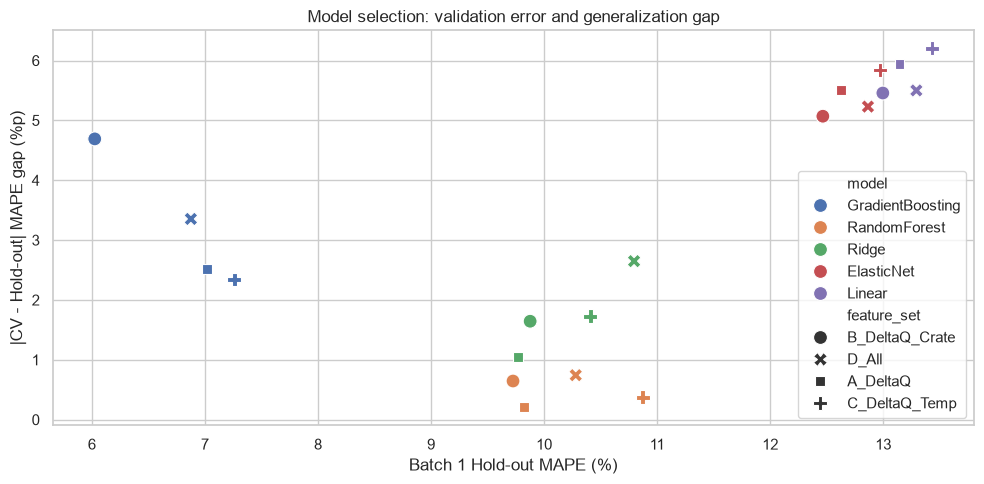

고정한 최종 조합: A_DeltaQ / Ridge


In [6]:
top_candidates = validation_results.head(8).copy()
display(top_candidates.round(3))

fig, ax = plt.subplots(figsize=(10, 5))
plot_data = validation_results.query("model != 'Dummy'").copy()
sns.scatterplot(
    data=plot_data, x="Valid_MAPE_%", y="CV_Valid_Gap",
    hue="model", style="feature_set", s=100, ax=ax,
)
ax.set(title="Model selection: validation error and generalization gap",
       xlabel="Batch 1 Hold-out MAPE (%)", ylabel="|CV - Hold-out| MAPE gap (%p)")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "01_model_selection.png", dpi=180, bbox_inches="tight")
plt.show()

# Batch 2의 C-rate 관측 범위가 거의 고정되어 있다는 Day 1 EDA를 반영한다.
# ΔQ 단독 Ridge는 교차검증과 Hold-out의 차이가 작아 배치 이동에 더 안정적인 후보로 판단했다.
FINAL_FEATURE_SET = "A_DeltaQ"
FINAL_MODEL = "Ridge"
print("고정한 최종 조합:", FINAL_FEATURE_SET, "/", FINAL_MODEL)

### 최종 모델 선택 결론

후보 모델은 Hold-out MAPE뿐 아니라 교차검증 평균, Fold별 표준편차, CV–Hold-out Gap, 모델 복잡도와 피처의 배치 간 안정성을 함께 고려해 비교하였다.

`B_DeltaQ_Crate + Gradient Boosting`은 Hold-out MAPE가 6.03%로 가장 낮았지만, CV MAPE가 10.72%, 표준편차가 4.66%p, CV–Hold-out Gap이 4.69%p로 나타나 검증 구간에 따른 성능 변동이 컸다. 또한 이 조합은 Batch 2에서 관측 범위가 거의 고정되는 C-rate에 의존하므로 다른 배치에서 효과가 유지되지 않을 가능성이 있다.

`A_DeltaQ + Random Forest`는 CV–Hold-out Gap이 0.21%p로 작았지만 CV 표준편차가 3.96%p였으며, 35개의 학습 셀에 비해 모델 구조가 복잡하다. 반면 `A_DeltaQ + Ridge`는 CV MAPE 8.72%, Hold-out MAPE 9.77%, 표준편차 1.85%p, Gap 1.05%p로 성능과 안정성의 균형이 가장 적절했다. Dummy Regressor의 Hold-out MAPE 16.49%보다도 충분히 낮아 ΔQ(V) 분산의 예측력을 확인할 수 있었다.

따라서 세 배치에서 일관된 관계가 확인된 `log10_deltaq_variance`만 입력으로 사용하는 Ridge Regression을 최종 모델로 확정하였다. 이 결정은 Batch 1의 교차검증과 Hold-out 결과만으로 이루어졌으며, 결정 이후 모델과 피처를 고정한 상태에서 Batch 2를 한 번만 평가한다.

## 7. Batch 2 최종 평가 — 모델 고정 후 한 번만 실행

`RUN_FINAL_TEST`는 최종 피처와 모델을 결정한 뒤에만 `True`로 변경한다. Batch 2 결과를 본 뒤 모델을 다시 고르면 테스트 데이터에 과적합되므로, 실행 이후에는 모델 구성을 수정하지 않는다.

,MAPE_%,MAE,RMSE,R2,Target_MAPE_%,Target_Test_Gap
0,38.392,186.533,197.517,0.189,9.1,29.292


,batch,cell_id,charging_policy,cycle_life,prediction,absolute_error,absolute_percentage_error_%
6,Batch 2,6,3.6C(9%)-5C,393.0,704.96,311.96,79.38
15,Batch 2,15,3.6C(9%)-5C,396.0,700.06,304.06,76.78
18,Batch 2,18,5.2C(50%)-4.25C,449.0,767.93,318.93,71.03
2,Batch 2,2,5.2C(50%)-4.25C,424.0,680.16,256.16,60.42
19,Batch 2,19,6C(60%)-3C,392.0,620.37,228.37,58.26
21,Batch 2,21,6C(60%)-3C,408.0,632.71,224.71,55.08
27,Batch 2,29,5.2C(58%)-4C,452.0,697.22,245.22,54.25
11,Batch 2,11,5.2C(50%)-4.25C,449.0,689.10,240.10,53.47
26,Batch 2,28,4.8C(80%)-4.8C,437.0,667.08,230.08,52.65
29,Batch 2,31,5.6C(26%)-4.5C,425.0,641.83,216.83,51.02


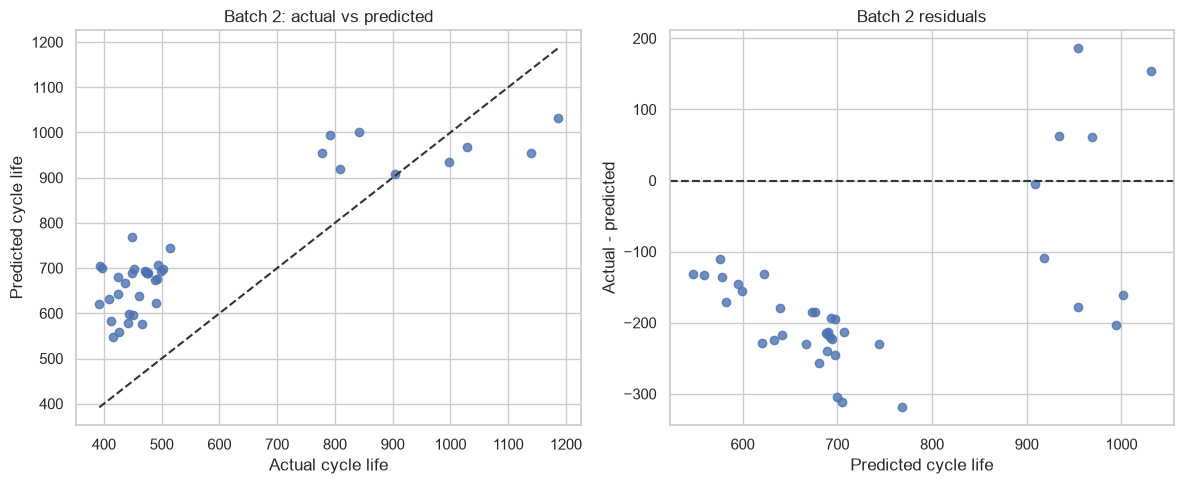

In [7]:
RUN_FINAL_TEST = True

if RUN_FINAL_TEST:
    selected_columns = FEATURE_SETS[FINAL_FEATURE_SET]
    final_model = clone(MODELS[FINAL_MODEL]).fit(
        batch1[selected_columns], batch1["cycle_life"]
    )
    batch2 = features.query("batch == 'Batch 2'").reset_index(drop=True)
    batch2_pred = final_model.predict(batch2[selected_columns])
    test_metrics = regression_metrics(batch2["cycle_life"], batch2_pred)
    test_metrics["Target_MAPE_%"] = 9.1
    test_metrics["Target_Test_Gap"] = test_metrics["MAPE_%"] - 9.1
    display(pd.DataFrame([test_metrics]).round(3))

    test_results = batch2[["batch", "cell_id", "charging_policy", "cycle_life"]].copy()
    test_results["prediction"] = batch2_pred
    test_results["absolute_error"] = abs(test_results["cycle_life"] - test_results["prediction"])
    test_results["absolute_percentage_error_%"] = (
        100 * test_results["absolute_error"] / test_results["cycle_life"]
    )
    display(test_results.sort_values("absolute_percentage_error_%", ascending=False).head(10).round(2))

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].scatter(test_results["cycle_life"], test_results["prediction"], alpha=0.8)
    low = min(test_results["cycle_life"].min(), test_results["prediction"].min())
    high = max(test_results["cycle_life"].max(), test_results["prediction"].max())
    axes[0].plot([low, high], [low, high], "--", color="#333333")
    axes[0].set(title="Batch 2: actual vs predicted", xlabel="Actual cycle life", ylabel="Predicted cycle life")
    axes[1].scatter(test_results["prediction"], test_results["cycle_life"] - test_results["prediction"], alpha=0.8)
    axes[1].axhline(0, linestyle="--", color="#333333")
    axes[1].set(title="Batch 2 residuals", xlabel="Predicted cycle life", ylabel="Actual - predicted")
    plt.tight_layout()
    fig.savefig(FIGURE_DIR / "02_batch2_predictions.png", dpi=180, bbox_inches="tight")
    plt.show()
else:
    print("최종 모델 결정 전이므로 Batch 2 테스트를 실행하지 않았습니다.")

### Batch 2 최종 평가 결론

Batch 1 전체 46개 셀로 다시 학습한 ΔQ(V) 분산 단독 Ridge 모델을 Batch 2의 유효 셀 39개에 한 번 적용하였다. Test MAPE는 38.39%로, Batch 1 Hold-out MAPE 9.77%보다 28.62%p 높았다. Batch 1 내부에서는 학습하지 않은 충전 정책에도 비교적 안정적이었지만, 수집 시점과 수명 분포가 다른 Batch 2에서는 성능이 유지되지 않았다.

MAE는 186.53사이클로, 예측값이 실제 수명에서 평균적으로 약 187사이클 벗어났다는 의미다. RMSE는 197.52사이클로 MAE보다 커 일부 셀에서 큰 오차가 발생했음을 보여준다. R²는 0.189로 Batch 2의 셀별 수명 차이를 충분히 설명하지 못했다.

실제값–예측값 그래프에서는 실제 수명이 약 400~500회인 단수명 셀의 예측값이 주로 550~770회에 형성되어 대각선 위에 분포하였다. 잔차 그래프에서도 이 셀들의 `실제값 - 예측값`이 음수로 나타나, 모델이 Batch 2의 단수명 셀을 실제보다 길게 예측하는 경향을 확인할 수 있었다.

원논문 MAPE 9.1%와의 차이는 29.29%p지만, 이번 분석은 과제 제공 파일과 결측 목표값 제외 기준을 사용해 원논문의 전처리·배치 구성을 그대로 재현한 실험이 아니다. 따라서 9.1%는 동일 조건의 직접 비교값이 아니라 참고 목표로 해석한다.

이 결과는 최종 모델의 외부 배치 일반화 한계를 보여주는 평가 결과다. Batch 2 성능을 확인한 뒤 피처나 모델을 다시 선택하면 테스트 데이터에 맞춘 결과가 되므로 현재 모델은 변경하지 않는다. 성능 저하 원인은 다음 단계에서 Batch 1과 Batch 2의 목표분포, 핵심 피처 분포 및 예측 오차 방향을 비교해 분석한다.

## 8. 배치 이동과 오차 분석

Batch 2의 실제 수명 중앙값은 Batch 1보다 크게 낮다. 최종 모델이 짧은 수명 셀을 높게 예측하는지 확인하고, 입력 피처와 목표분포가 배치 사이에서 얼마나 이동했는지 비교한다.

,test_cells,over_prediction_%,mean_signed_error,median_APE_%,max_APE_%
0,39,89.74,162.75,38.87,79.38


,cells,life_median,life_min,life_max,deltaq_median,temperature_median
batch,,,,,,
Batch 1,46,858.5,534.0,1227.0,-3.851,32.474
Batch 2,39,472.0,392.0,1186.0,-3.487,33.016
Batch 3,44,1005.5,541.0,1935.0,-4.175,34.111


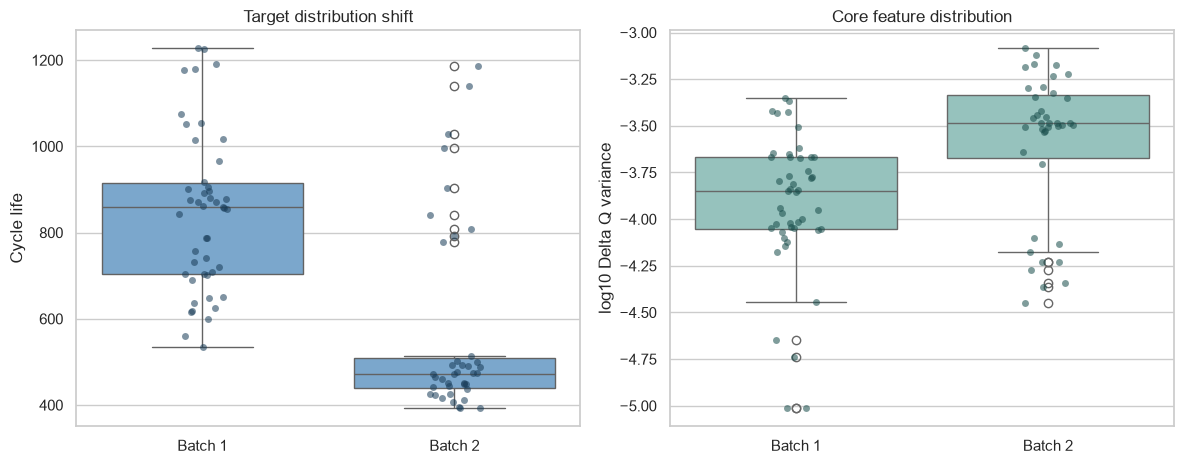

In [8]:
if RUN_FINAL_TEST:
    test_results["signed_error_prediction_minus_actual"] = (
        test_results["prediction"] - test_results["cycle_life"]
    )
    error_summary = pd.DataFrame([{
        "test_cells": len(test_results),
        "over_prediction_%": 100 * (test_results["signed_error_prediction_minus_actual"] > 0).mean(),
        "mean_signed_error": test_results["signed_error_prediction_minus_actual"].mean(),
        "median_APE_%": test_results["absolute_percentage_error_%"].median(),
        "max_APE_%": test_results["absolute_percentage_error_%"].max(),
    }])
    display(error_summary.round(2))

    batch_shift = features.groupby("batch").agg(
        cells=("cell_id", "count"),
        life_median=("cycle_life", "median"),
        life_min=("cycle_life", "min"),
        life_max=("cycle_life", "max"),
        deltaq_median=("log10_deltaq_variance", "median"),
        temperature_median=("mean_Tavg_first100", "median"),
    )
    display(batch_shift.round(3))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
    sns.boxplot(data=features.query("batch in ['Batch 1', 'Batch 2']"),
                x="batch", y="cycle_life", color="#6EA8D9", ax=axes[0])
    sns.stripplot(data=features.query("batch in ['Batch 1', 'Batch 2']"),
                  x="batch", y="cycle_life", color="#173B57", alpha=0.55, ax=axes[0])
    axes[0].set(title="Target distribution shift", xlabel="", ylabel="Cycle life")
    sns.boxplot(data=features.query("batch in ['Batch 1', 'Batch 2']"),
                x="batch", y="log10_deltaq_variance", color="#8FC9C2", ax=axes[1])
    sns.stripplot(data=features.query("batch in ['Batch 1', 'Batch 2']"),
                  x="batch", y="log10_deltaq_variance", color="#174C4A", alpha=0.55, ax=axes[1])
    axes[1].set(title="Core feature distribution", xlabel="", ylabel="log10 Delta Q variance")
    plt.tight_layout()
    fig.savefig(FIGURE_DIR / "03_batch_shift.png", dpi=180, bbox_inches="tight")
    plt.show()

## 9. Performance Reporting

교수님 가이드의 형식에 맞춰 Batch 1 교차검증, Batch 1 Hold-out, Batch 2 Test와 세 가지 Gap을 구분한다. Gap은 뒤 단계 MAPE에서 앞 단계 MAPE를 뺀 값으로, 양수일수록 일반화 성능 저하가 크다는 뜻이다.

In [9]:
selected_result = validation_results.query(
    "feature_set == @FINAL_FEATURE_SET and model == @FINAL_MODEL"
).iloc[0]
train_cv_mape = selected_result["CV_MAPE_%"]
valid_mape = selected_result["Valid_MAPE_%"]
test_mape = test_metrics["MAPE_%"]
paper_target_mape = 9.1

performance_report = pd.DataFrame([
    {"구분": "Train (Batch 1 CV)", "MAPE (%)": train_cv_mape, "비고": "정책 그룹 기반 5-fold CV 평균"},
    {"구분": "Valid (Batch 1 Hold-out)", "MAPE (%)": valid_mape, "비고": "학습과 충전 정책이 겹치지 않는 11개 셀"},
    {"구분": "Test (Batch 2)", "MAPE (%)": test_mape, "비고": "최종 모델 고정 후 1회 평가"},
    {"구분": "Gap (Train-Valid)", "MAPE (%)": valid_mape - train_cv_mape, "비고": "양수이면 과적합 가능성"},
    {"구분": "Gap (Valid-Test)", "MAPE (%)": test_mape - valid_mape, "비고": "양수이면 배치 간 일반화 저하"},
    {"구분": "Gap (Target-Test)", "MAPE (%)": test_mape - paper_target_mape, "비고": "참고 목표: 원논문 9.1%"},
])

RESULT_DIR = PROJECT_DIR / "results"
RESULT_DIR.mkdir(parents=True, exist_ok=True)
performance_report.to_csv(RESULT_DIR / "model_performance.csv", index=False)
validation_results.to_csv(RESULT_DIR / "candidate_model_results.csv", index=False)
test_results.to_csv(RESULT_DIR / "batch2_predictions.csv", index=False)
error_summary.to_csv(RESULT_DIR / "batch2_error_summary.csv", index=False)
batch_shift.reset_index().to_csv(RESULT_DIR / "batch_shift_summary.csv", index=False)

display(performance_report.round(3))

구분,MAPE (%),비고
Train (Batch 1 CV),8.719,정책 그룹 기반 5-fold CV 평균
Valid (Batch 1 Hold-out),9.768,학습과 충전 정책이 겹치지 않는 11개 셀
Test (Batch 2),38.392,최종 모델 고정 후 1회 평가
Gap (Train-Valid),1.049,양수이면 과적합 가능성
Gap (Valid-Test),28.624,양수이면 배치 간 일반화 저하
Gap (Target-Test),29.292,참고 목표: 원논문 9.1%


## 10. 최종 결론

Batch 1에서 `log10 ΔQ(V) 분산` 단독 Ridge 모델을 최종 모델로 결정했다. 교차검증 MAPE는 8.72%, Hold-out MAPE는 9.77%이며 Train-Valid Gap이 +1.05%p로 작다. Hold-out 성능이 더 낮은 조합도 있었지만, 작은 표본에서 변동성이 크거나 Batch 2에서 관측 범위가 거의 사라지는 C-rate에 의존하므로 채택하지 않았다.

고정된 모델의 Batch 2 Test MAPE는 38.39%다. Valid-Test Gap은 +28.62%p, 원논문 참고 목표 9.1%와의 Gap은 +29.29%p다. Batch 2 셀의 89.74%를 실제보다 높게 예측했고 평균 과대 예측은 162.75사이클이었다. Batch 2 수명 중앙값이 472회로 Batch 1의 858.5회보다 크게 낮은 목표분포 이동이 주된 실패 원인으로 확인됐다.

따라서 현재 모델은 초기 열화 위험을 선별하는 연구용 기준선으로는 사용할 수 있지만, ESS 교체 시점을 자동 결정하는 용도로는 부족하다. 다음 개발에서는 초기 용량·충전 시간·온도 변화량을 사전에 정의해 추가하고, 배치 차이를 보정한 뒤 새로운 외부 배치에서 검증해야 한다. Batch 2 결과를 반복해서 보며 모델을 다시 고르는 방식은 테스트 과적합을 만들므로 사용하지 않는다.